# Linear Regression

## 1) Simple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### a) Is there a relationship between the year an exoplanet was discovered and its distance from Earth?

In [2]:
df = sns.load_dataset('planets')
df.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [5]:
df.dropna(subset=['orbital_period','mass','distance'],inplace=True)

In [6]:
data = {
    "Year" : df['year'],
    "Distance": df['distance']
}

df1 = pd.DataFrame(data)
display(df1)

,Year,Distance
0,2006,77.40
1,2008,56.95
2,2011,19.84
3,2007,110.62
4,2009,119.47
...,...,...
640,2009,14.90
641,2013,44.46
642,1999,17.24
649,2013,178.00


##### Make a dataframe of the feature (year) and output to predict (distance)

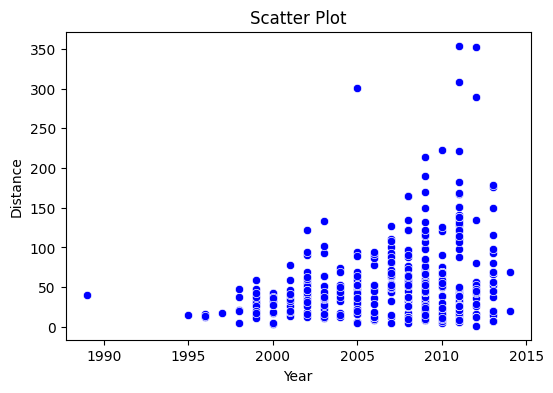

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Year',y='Distance',data=df1,color='blue')
plt.title('Scatter Plot')
plt.show()

In [9]:
X = df1['Year'].values
Y = df1['Distance'].values

X_b = np.c_[np.ones((len(X),1)),X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)

intercept, slope = theta_best

print("Intercept: ",intercept)
print("Slope: ",slope)

Intercept:  -4281.8124528309445
Slope:  2.158976397815788


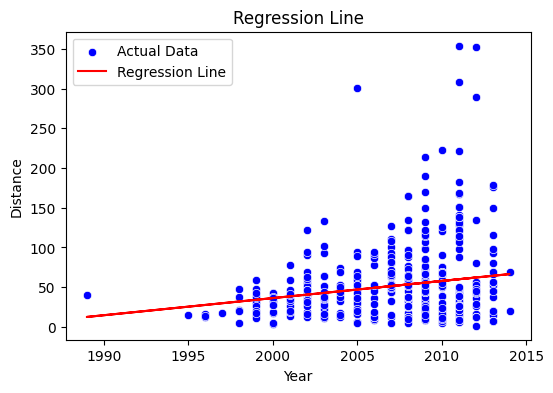

In [11]:
Y_pred = intercept + slope * X
plt.figure(figsize=(6,4))
sns.scatterplot(x='Year',y='Distance',data=df1,color='blue',label='Actual Data')
plt.plot(X,Y_pred,color='red',label='Regression Line')
plt.title('Regression Line')
plt.legend()
plt.show()

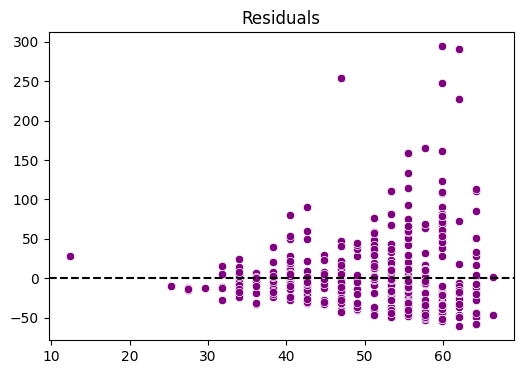

In [13]:
residuals = Y - Y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=Y_pred,y=residuals,color='purple')
plt.axhline(0,color='black',linestyle='--')
plt.title('Residuals')
plt.show()

In [14]:
SS_res = np.sum(residuals**2)
SS_tot = np.sum((Y-np.mean(Y))**2)
R2 = 1 - (SS_res / SS_tot)

print('R^2 score: ',R2)

R^2 score:  0.037282402842050644


In [15]:
results = {'Actual':Y,'Predicted':Y_pred}
res = pd.DataFrame(results)
display(res)

,Actual,Predicted
0,77.40,49.094201
1,56.95,53.412154
2,19.84,59.889083
3,110.62,51.253178
4,119.47,55.571130
...,...,...
493,14.90,55.571130
494,44.46,64.207036
495,17.24,33.981366
496,178.00,64.207036


### Inference

A simple linear regression was performed to study the relationship between **year of discovery** and **distance of exoplanets**.

The regression equation obtained was:

### distance = −4281.81 + 2.16 × year

The model indicates a **positive relationship** — as the year increases, the average distance of discovered planets also increases. This trend aligns with scientific expectations, as improvements in telescope technology and detection methods allow the discovery of planets located farther from Earth.

However, the model’s **R² score of 0.037** suggests that only 3.7% of the variance in planet distance is explained by year. This means the relationship is **weak**, and many other factors influence how far away discovered planets are.

Overall, while the trend is in the expected direction, the simple linear regression model is not a good predictor of planet distance on its own.

### b) Is there a relationship between the distance of exoplanets from Earth and their orbital periods?

In [16]:
log_distance = np.log1p(df['distance'])   #log(1 + distance)
log_orbital_period = np.log1p(df['orbital_period'])  #log(1 + orbital_period)

data = {
    "Distance": log_distance,
    "Orbital_Period": log_orbital_period
}
df1 = pd.DataFrame(data)
display(df1)

,Distance,Orbital_Period
0,4.361824,5.599532
1,4.059581,6.775108
2,3.036874,6.638568
3,4.715100,5.790052
4,4.791401,6.248468
...,...,...
640,2.766319,4.724729
641,3.816833,1.800141
642,2.903617,5.743926
649,5.187386,1.309249


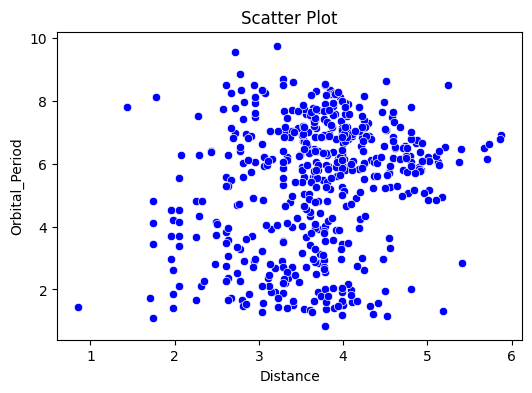

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Distance',y='Orbital_Period',data=df1,color='blue')
plt.title('Scatter Plot')
plt.show()

In [19]:
X = df1['Distance'].values
Y = df1['Orbital_Period'].values

X_b = np.c_[np.ones((len(X),1)),X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)

intercept, slope = theta_best
print("Intercept: ",intercept)
print("Slope: ",slope)

Intercept:  3.193022320958881
Slope:  0.580212957322929


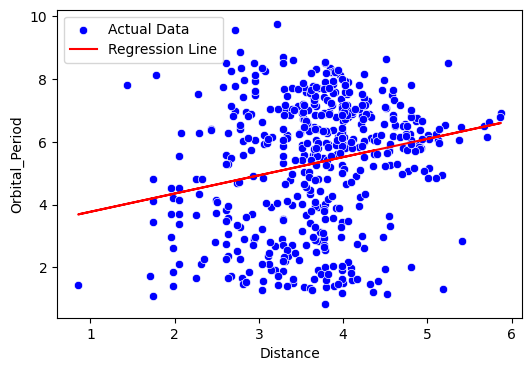

In [20]:
Y_pred = intercept + slope * X

plt.figure(figsize=(6,4))
sns.scatterplot(x='Distance',y='Orbital_Period',data=df1,color='blue',label='Actual Data')
plt.plot(X,Y_pred,color='red',label='Regression Line')
plt.legend()
plt.show()

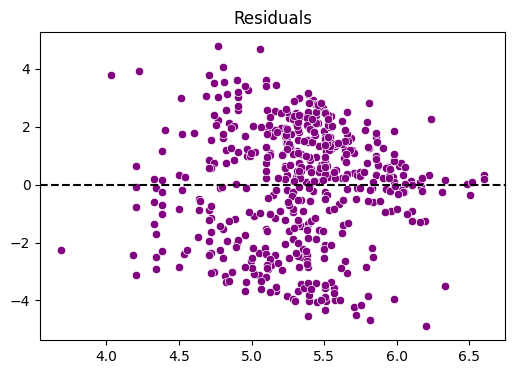

In [21]:
residuals = Y - Y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=Y_pred,y=residuals,color='purple')
plt.axhline(0,color='black',linestyle='--')
plt.title('Residuals')
plt.show()

In [22]:
SS_res = np.sum(residuals**2)
SS_tot = np.sum((Y - np.mean(Y))**2)
R2 = 1 - (SS_res / SS_tot)

print('R^2 score: ',R2)

R^2 score:  0.04876495653903179


In [23]:
results = {'Actual':Y,'Predicted':Y_pred}
res = pd.DataFrame(results)
display(res)

,Actual,Predicted
0,5.599532,5.723809
1,6.775108,5.548444
2,6.638568,4.955056
3,5.790052,5.928785
4,6.248468,5.973055
...,...,...
493,4.724729,4.798077
494,1.800141,5.407598
495,5.743926,4.877739
496,1.309249,6.202811


### Inference

A log-log simple linear regression was performed to examine the relationship between the **distance of exoplanets** and their **orbital periods**.
The regression equation obtained was:

### log(Orbital_Period) = 3.193 + log(Distance) * 0.58

The positive slope indicates that, on average, **planets farther from Earth tend to have longer orbital periods**, which aligns with theoretical expectations.
However, the **R² score of 0.049** shows that distance explains only a small fraction of the variation in orbital period.
This weak correlation suggests that **other factors, such as the planet’s semi-major axis and detection method, play a much larger role** in determining orbital period.
Overall, the log-log transformation helped linearize the relationship and interpret the slope as a percentage change, but distance alone is not a strong predictor.

## 2) Multiple Linear Regression

### a) How do the distance of a planet from Earth and its mass affect its orbital period?

In [25]:
log_distance = np.log1p(df['distance'])
log_mass = np.log1p(df['mass'])
log_orbital_period = np.log1p(df['orbital_period'])

data = {
    'Distance':log_distance,
    'Mass':log_mass,
    'Orbital_Period':log_orbital_period
}
df1 = pd.DataFrame(data)
display(df1)

,Distance,Mass,Orbital_Period
0,4.361824,2.091864,5.599532
1,4.059581,1.166271,6.775108
2,3.036874,1.280934,6.638568
3,4.715100,3.015535,5.790052
4,4.791401,2.442347,6.248468
...,...,...,...
640,2.766319,1.131402,4.724729
641,3.816833,0.726582,1.800141
642,2.903617,1.078410,5.743926
649,5.187386,0.904218,1.309249


In [26]:
X = df1[['Distance','Mass']].values
Y = df1['Orbital_Period']

X_b = np.c_[np.ones((len(X),1)),X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)

print("Coefficients: ",theta_best)

Coefficients:  [3.94222678 0.06639148 1.25433541]


,Actual,Predicted
0,5.599532,6.855714
1,6.775108,5.674643
2,6.638568,5.750570
3,5.790052,8.037761
4,6.248468,7.323857
...,...,...
640,4.724729,5.545045
641,1.800141,5.107009
642,5.743926,5.487690
649,1.309249,5.420818


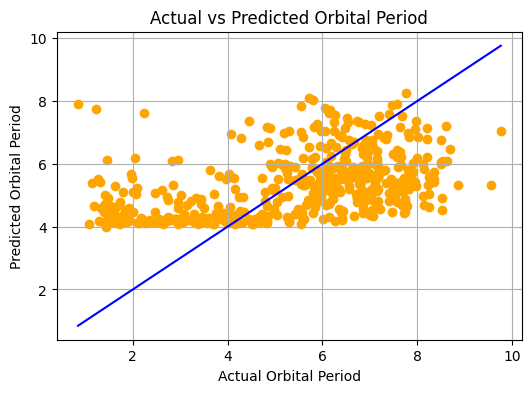

In [27]:
Y_pred = X_b.dot(theta_best)

results = pd.DataFrame({'Actual':Y,'Predicted':Y_pred})
display(results)

plt.figure(figsize=(6,4))
plt.scatter(Y,Y_pred,color='orange')
minv = min(min(Y),min(Y_pred))
maxv = max(max(Y),max(Y_pred))
plt.plot([minv,maxv],[minv,maxv],color='blue')
plt.xlabel('Actual Orbital Period')
plt.ylabel('Predicted Orbital Period')
plt.title('Actual vs Predicted Orbital Period')
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Residuals')

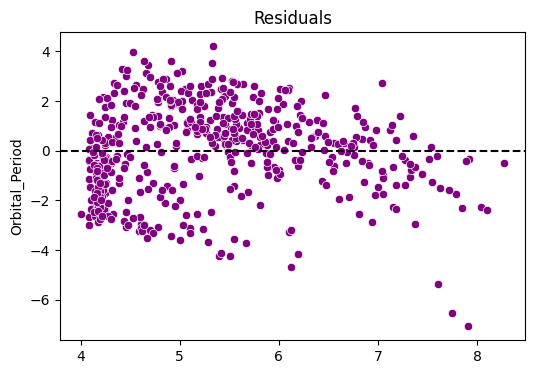

In [28]:
residuals = Y - Y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=Y_pred, y=residuals,color='purple')
plt.axhline(0,color='black',linestyle='--')
plt.title('Residuals')

In [29]:
SS_res = np.sum(residuals**2)
SS_tot = np.sum((Y - np.mean(Y))**2)

R2 = 1 - (SS_res / SS_tot)

print("R2 score: ",R2)

R2 score:  0.23210417408445216


### Inference

A multiple linear regression was performed to predict the logarithm of a planet’s orbital period using the logarithm of its distance from Earth and its mass. The resulting regression equation is:

log(Orbital_Period) = 3.942 + log(Distance) * 0.06

Key findings:

**Mass is the dominant predictor**: The coefficient of log(mass) (1.254) indicates that holding distance constant, a 1% increase in planetary mass is associated with approximately a 1.25% increase in orbital period.

**Distance has a minimal effect**: The coefficient of log(distance) (0.066) is small, suggesting that once mass is accounted for, distance contributes very little to predicting orbital period.

**Model performance**: The R² score of ~0.23 shows that about 23% of the variation in orbital period is explained by these two variables. This is an improvement over single-variable regressions, though a large portion of the variation remains unexplained, likely due to other factors such as host star properties or detection biases.